In [ ]:
My goals for this assignment are to compare two different works from the same author Brandon Sanderson. Essentially for the first part of the assignment I want to answer how have Brandon Sanderson's word-use patterns changed between his early and later writing career. My sources will be equal-sized excerpts from Elantris, published in 2005, and The Sunlit Man, published in 2023.

For the second part of the assignment, I want to compare Sanderson's word-use patterns with those of an older fantasy author, J.R.R. Tolkien. By comparing equal-sized excerpts from their works, I want to examine how word frequences and vocabulary may differ between classic and contemporary fantasy writing. This comparison keeps the genre relatively consistent while allowing me to explore how writing styles may have changed across a large period of time.

In [14]:
# Comparing Sanderson older works - Baseline
# Elantris (2005) vs The Sunlit Man (2023)
# Imports
import requests
import re
import nltk
from bs4 import BeautifulSoup
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('stopwords')

stop_words = set(nltk.corpus.stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/pmarino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# getting the actual chapter text

def get_text(url):
    r = requests.get(url)
    soup = BeautifulSoup(r.text, 'html.parser')

    content = soup.select_one('.article-template__content')

    if content is None:
        content = soup.find('main')

    # only collect paragraph text
    paragraphs = content.find_all('p')

    text = " ".join(
        p.get_text(" ", strip=True)
        for p in paragraphs
    )

    return text

In [7]:
# URLs
elantris_urls = [
    "https://www.brandonsanderson.com/blogs/blog/elantris-chapter-one",
    "https://www.brandonsanderson.com/blogs/blog/elantris-chapter-two",
    "https://www.brandonsanderson.com/blogs/blog/elantris-chapter-three"
]

sunlit_urls = [
    "https://www.brandonsanderson.com/blogs/blog/the-sunlit-man-chapter-one",
    "https://www.brandonsanderson.com/blogs/blog/the-sunlit-man-chapter-two",
    "https://www.brandonsanderson.com/blogs/blog/the-sunlit-man-chapter-three",
    "https://www.brandonsanderson.com/blogs/blog/the-sunlit-man-chapter-four"
]

In [16]:
# Combining the chapters
elantris_text = " ".join(get_text(url) for url in elantris_urls)
sunlit_text = " ".join(get_text(url) for url in sunlit_urls)

print("Elantris characters:", len(elantris_text))
print("Sunlit Man characters:", len(sunlit_text))

print("\nELANTRIS START:")
print(elantris_text[:500])

print("\nSUNLIT MAN START:")
print(sunlit_text[:500])

Elantris characters: 72638
Sunlit Man characters: 52935

ELANTRIS START:
Prince Raoden of Arelon awoke early that morning, completely unaware that he had been damned for all eternity. Still drowsy, Raoden sat up, blinking in the soft morning light. Just outside his open balcony windows he could see the enormous city of Elantris in the distance, its stark walls casting a deep shadow over the smaller city of Kae, where Raoden lived. Elantris’s walls were incredibly high, but Raoden could see the tops of black towers rising behind them, their broken spires a clue to the

SUNLIT MAN START:
 He blinked, his right cheek in the dirt. Then he focused on the incongruous sight of a plant growing in fast-motion before his eyes. Was he dreaming? The fragile sprout quivered and twisted, heaving up from the earth. It seemed to stretch with joy, its seedpods parting like arms after a deep sleep. A stalk emerged from the center, testing the air like a serpent’s tongue. Then it stretched left toward th

In [18]:
# clean and tokenize
def tokenize(text):
    text = text.lower()

    # grab words and ignore punctuation/numbers
    words = re.findall(r"\b[a-zA-Z']+\b", text)

    return words


elantris_words = tokenize(elantris_text)
sunlit_words = tokenize(sunlit_text)

print("Elantris words available:", len(elantris_words))
print("Sunlit Man words available:", len(sunlit_words))

Elantris words available: 13134
Sunlit Man words available: 9578


In [19]:
EXCERPT_SIZE = 9500

elantris_excerpt = elantris_words[:EXCERPT_SIZE]
sunlit_excerpt = sunlit_words[:EXCERPT_SIZE]

print("Elantris excerpt:", len(elantris_excerpt))
print("Sunlit Man excerpt:", len(sunlit_excerpt))

Elantris excerpt: 9500
Sunlit Man excerpt: 9500


In [23]:
# removing stop words and count frequencies
def word_frequency(words):
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return Counter(filtered_words)

elantris_freq = word_frequency(elantris_excerpt)
sunlit_freq = word_frequency(sunlit_excerpt)

print("Elantris:")
print(elantris_freq.most_common(20))

print("\nThe Sunlit Man:")
print(sunlit_freq.most_common(20))

print("Elantris non-stop words:", sum(elantris_freq.values()))
print("Sunlit Man non-stop words:", sum(sunlit_freq.values()))

Elantris:
[('raoden', 108), ('sarene', 76), ('said', 56), ('one', 47), ('would', 42), ('man', 39), ('father', 35), ('galladon', 34), ('ashe', 32), ('like', 28), ('city', 25), ('elantris', 25), ('arelon', 23), ('could', 23), ('lady', 23), ('prince', 22), ('head', 22), ('even', 22), ('iadon', 22), ('eyes', 21)]

The Sunlit Man:
[('nomad', 147), ('eyes', 51), ('man', 49), ('one', 45), ('could', 39), ('ember', 39), ('like', 38), ('glowing', 36), ('said', 30), ('people', 27), ('though', 27), ('auxiliary', 24), ('light', 23), ('woman', 23), ('even', 21), ('would', 20), ('toward', 19), ('long', 19), ('skin', 19), ('something', 19)]
Elantris non-stop words: 4852
Sunlit Man non-stop words: 4892


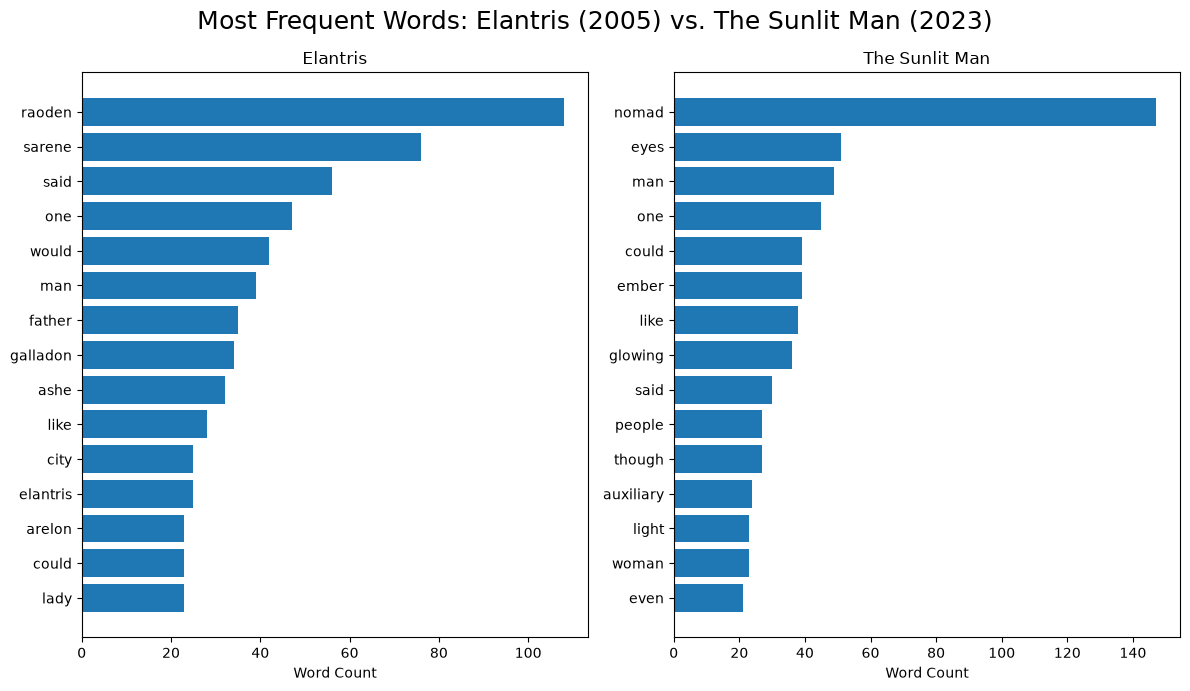

In [24]:
# Graph 1 - Bar Graph of most frequent words between the two novels
# Get the 15 most frequent words from each book
elantris_top = elantris_freq.most_common(15)[::-1]
sunlit_top = sunlit_freq.most_common(15)[::-1]

# Create side-by-side graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

fig.suptitle(
    "Most Frequent Words: Elantris (2005) vs. The Sunlit Man (2023)",
    fontsize=18
)

# Elantris
ax1.barh(
    [word for word, count in elantris_top],
    [count for word, count in elantris_top]
)

ax1.set_title("Elantris")
ax1.set_xlabel("Word Count")

# The Sunlit Man
ax2.barh(
    [word for word, count in sunlit_top],
    [count for word, count in sunlit_top]
)

ax2.set_title("The Sunlit Man")
ax2.set_xlabel("Word Count")

plt.tight_layout()
plt.show()

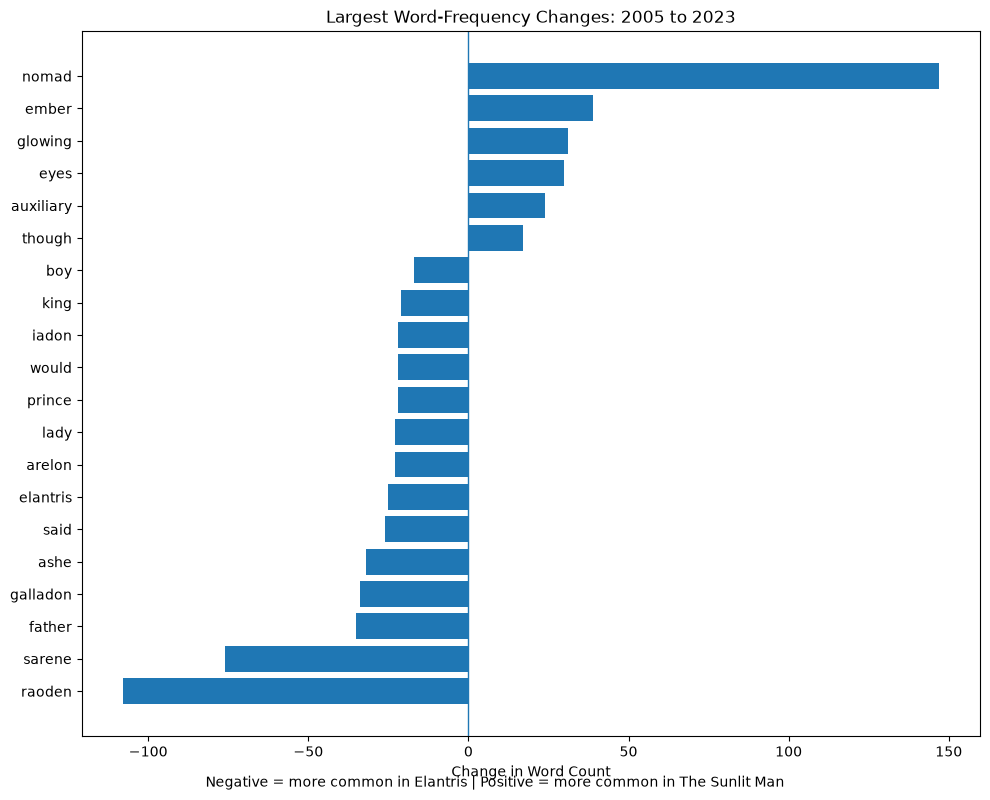

In [25]:
# Graph 2 - Biggest changes between 2005 and 2023
# Get every word that appears in either excerpt
all_words = set(elantris_freq.keys()) | set(sunlit_freq.keys())

# Calculate change:
# positive = used more in The Sunlit Man
# negative = used more in Elantris
differences = {}

for word in all_words:
    differences[word] = sunlit_freq[word] - elantris_freq[word]

# Get the 20 words with the largest absolute difference
largest_changes = sorted(
    differences.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)[:20]

# Sort for graph
largest_changes = sorted(largest_changes, key=lambda x: x[1])

words = [word for word, difference in largest_changes]
changes = [difference for word, difference in largest_changes]

plt.figure(figsize=(10, 8))

plt.barh(words, changes)

plt.axvline(0, linewidth=1)

plt.title("Largest Word-Frequency Changes: 2005 to 2023")
plt.xlabel("Change in Word Count")

plt.figtext(
    0.5, 0.01,
    "Negative = more common in Elantris | Positive = more common in The Sunlit Man",
    ha="center"
)

plt.tight_layout()
plt.show()

In [32]:
# 2nd analysis filtering world-specific words
book_specific_words = {
    # Elantris
    'raoden', 'sarene', 'galladon', 'ashe',
    'elantris', 'arelon', 'iadon',

    # The Sunlit Man
    'nomad', 'auxiliary', 'ember',
    'sun', 'ship', 'mud', 'crowd'
}

In [33]:
def filtered_word_frequency(words):
    filtered_words = [
        word for word in words
        if word not in stop_words
        and word not in book_specific_words
    ]

    return Counter(filtered_words)

elantris_filtered_freq = filtered_word_frequency(elantris_excerpt)
sunlit_filtered_freq = filtered_word_frequency(sunlit_excerpt)

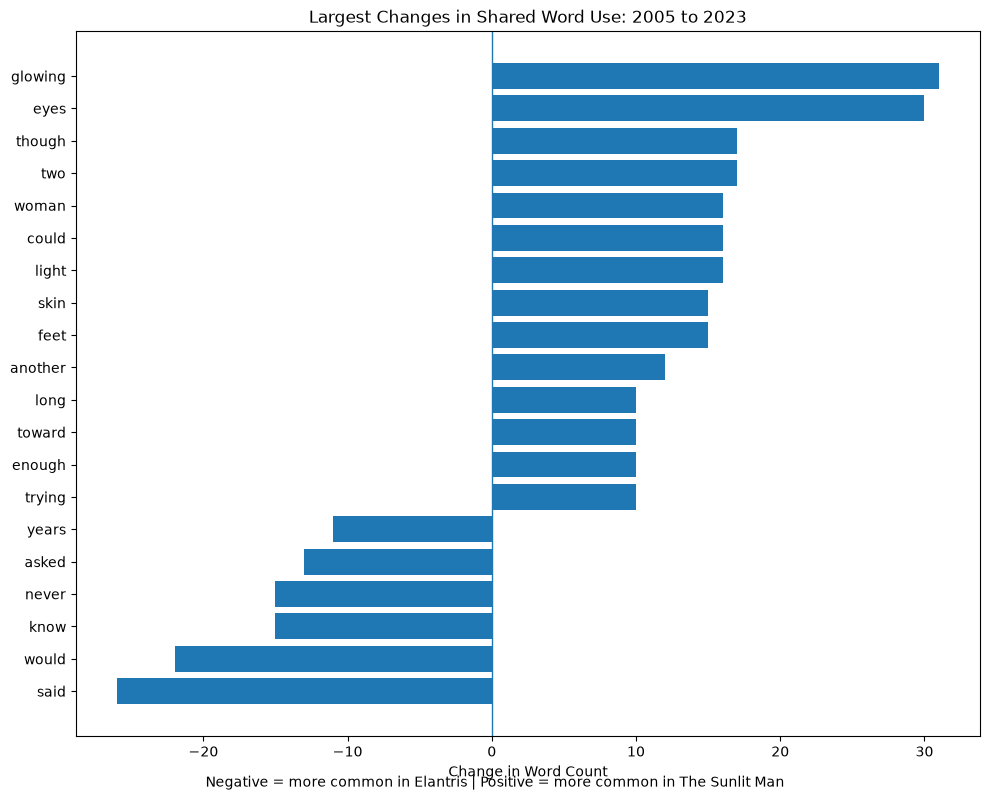

In [34]:
shared_words = (
    set(elantris_filtered_freq.keys())
    & set(sunlit_filtered_freq.keys())
)

differences = {}

for word in shared_words:
    differences[word] = (
        sunlit_filtered_freq[word]
        - elantris_filtered_freq[word]
    )

largest_changes = sorted(
    differences.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)[:20]

largest_changes = sorted(
    largest_changes,
    key=lambda x: x[1]
)

words = [word for word, difference in largest_changes]
changes = [difference for word, difference in largest_changes]

plt.figure(figsize=(10, 8))

plt.barh(words, changes)

plt.axvline(0, linewidth=1)

plt.title("Largest Changes in Shared Word Use: 2005 to 2023")
plt.xlabel("Change in Word Count")

plt.figtext(
    0.5,
    0.01,
    "Negative = more common in Elantris | Positive = more common in The Sunlit Man",
    ha="center"
)

plt.tight_layout()
plt.show()

In [39]:
# Part 2 Sanderson vs Lord Dunsany 
# Lord Dunsany - The King of Elfland's Daughter
dunsany_url = "https://www.gutenberg.org/cache/epub/61077/pg61077.txt"

In [40]:
def get_gutenberg_text(url):
    r = requests.get(url)
    r.raise_for_status()

    text = r.text

    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK THE KING OF ELFLAND'S DAUGHTER ***"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK THE KING OF ELFLAND'S DAUGHTER ***"

    start = text.find(start_marker)
    end = text.find(end_marker)

    if start != -1:
        text = text[start + len(start_marker):]

    if end != -1:
        text = text[:end]

    return text

In [41]:
dunsany_text = get_gutenberg_text(dunsany_url)

print("Dunsany characters:", len(dunsany_text))

print("\nDUNSANY START:")
print(dunsany_text[:500])

Dunsany characters: 381944

DUNSANY START:





                      The King of Elfland's Daughter

                              Lord Dunsany


                           BALLANTINE BOOKS
                               NEW YORK

              First Ballantine Books edition: June, 1969

                           Printed in Canada

                        BALLANTINE BOOKS, INC.
                101 Fifth Avenue, New York, N.Y. 10003


                                  TO
                             LADY DUNSANY



In [42]:
# starting at chapter 1
chapter_one = "CHAPTER I"

start = dunsany_text.find(chapter_one)

if start != -1:
    dunsany_text = dunsany_text[start:]

print(dunsany_text[:500])

CHAPTER I

                  _The Plan of the Parliament of Erl_


In their ruddy jackets of leather that reached to their knees the men of
Erl appeared before their lord, the stately white-haired man in his long
red room. He leaned in his carven chair and heard their spokesman.

And thus their spokesman said.

"For seven hundred years the chiefs of your race have ruled us well; and
their deeds are remembered by the minor minstrels, living on yet in
their little tinkling songs. And 


In [43]:
# tokenize Dunsany
dunsany_words = tokenize(dunsany_text)

print("Dunsany words available:", len(dunsany_words))

Dunsany words available: 69785


In [44]:
# equalize the excerpts
EXCERPT_SIZE = 9500

dunsany_excerpt = dunsany_words[:EXCERPT_SIZE]
sunlit_dunsany_excerpt = sunlit_words[:EXCERPT_SIZE]

print("Dunsany excerpt:", len(dunsany_excerpt))
print("Sunlit Man excerpt:", len(sunlit_dunsany_excerpt))

Dunsany excerpt: 9500
Sunlit Man excerpt: 9500


In [45]:
# Baseline Sanderson vs Dunsany
dunsany_freq = word_frequency(dunsany_excerpt)
sunlit_dunsany_freq = word_frequency(sunlit_dunsany_excerpt)

print("The King of Elfland's Daughter:")
print(dunsany_freq.most_common(20))

print("\nThe Sunlit Man:")
print(sunlit_dunsany_freq.most_common(20))

The King of Elfland's Daughter:
[('alveric', 77), ('sword', 59), ('fields', 48), ('said', 35), ('elfland', 35), ('would', 34), ('know', 33), ('came', 33), ('one', 29), ('erl', 28), ('man', 28), ('old', 27), ('come', 25), ('witch', 25), ('told', 23), ('lirazel', 23), ('wood', 23), ('knew', 22), ('little', 21), ('though', 21)]

The Sunlit Man:
[('nomad', 147), ('eyes', 51), ('man', 49), ('one', 45), ('could', 39), ('ember', 39), ('like', 38), ('glowing', 36), ('said', 30), ('people', 27), ('though', 27), ('auxiliary', 24), ('light', 23), ('woman', 23), ('even', 21), ('would', 20), ('toward', 19), ('long', 19), ('skin', 19), ('something', 19)]


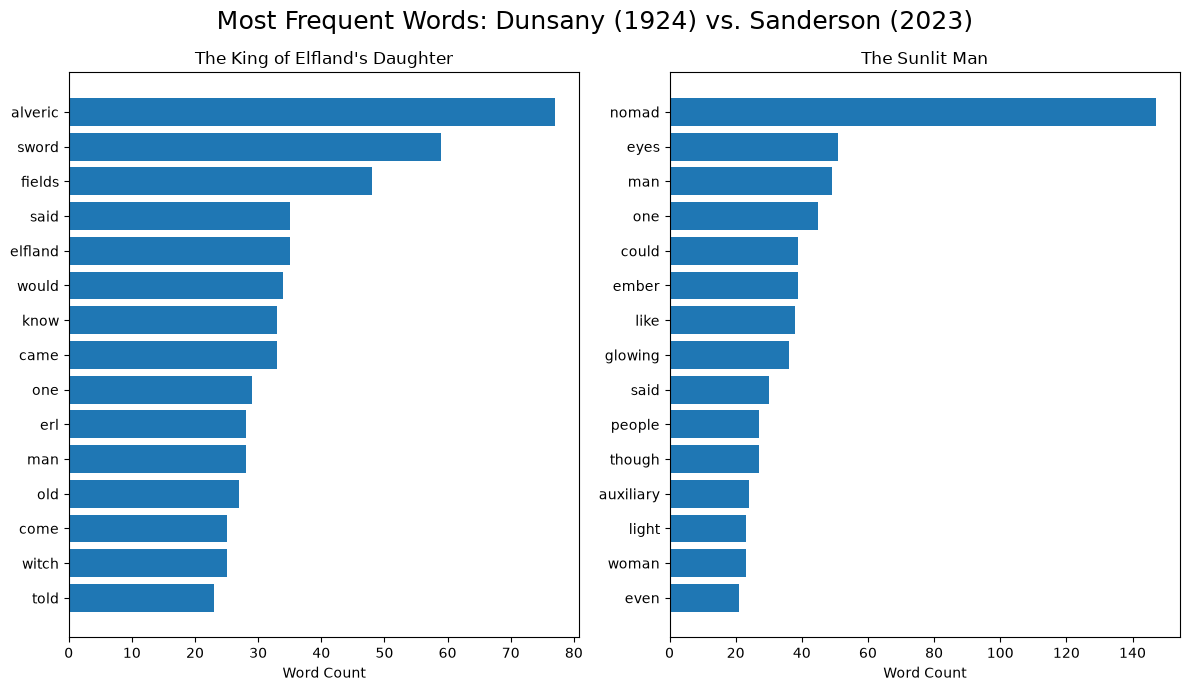

In [46]:
# side by side graph
dunsany_top = dunsany_freq.most_common(15)[::-1]
sunlit_top = sunlit_dunsany_freq.most_common(15)[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

fig.suptitle(
    "Most Frequent Words: Dunsany (1924) vs. Sanderson (2023)",
    fontsize=18
)

ax1.barh(
    [word for word, count in dunsany_top],
    [count for word, count in dunsany_top]
)

ax1.set_title("The King of Elfland's Daughter")
ax1.set_xlabel("Word Count")

ax2.barh(
    [word for word, count in sunlit_top],
    [count for word, count in sunlit_top]
)

ax2.set_title("The Sunlit Man")
ax2.set_xlabel("Word Count")

plt.tight_layout()
plt.show()

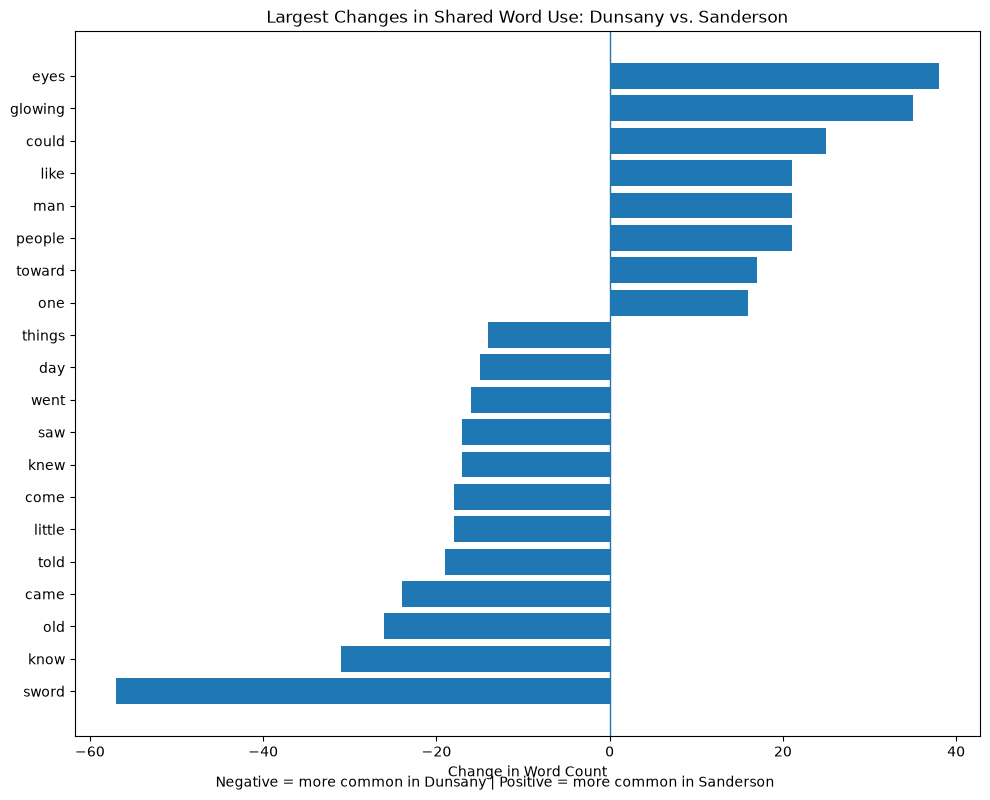

In [47]:
# difference graph
shared_words = (
    set(dunsany_freq.keys())
    & set(sunlit_dunsany_freq.keys())
)

differences = {}

for word in shared_words:
    differences[word] = (
        sunlit_dunsany_freq[word]
        - dunsany_freq[word]
    )

largest_changes = sorted(
    differences.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)[:20]

largest_changes = sorted(
    largest_changes,
    key=lambda x: x[1]
)

words = [word for word, difference in largest_changes]
changes = [difference for word, difference in largest_changes]

plt.figure(figsize=(10, 8))

plt.barh(words, changes)

plt.axvline(0, linewidth=1)

plt.title(
    "Largest Changes in Shared Word Use: Dunsany vs. Sanderson"
)

plt.xlabel("Change in Word Count")

plt.figtext(
    0.5,
    0.01,
    "Negative = more common in Dunsany | Positive = more common in Sanderson",
    ha="center"
)

plt.tight_layout()
plt.show()

In [49]:
# filtering
# 2nd analysis filtering book-specific words
book_specific_words_dunsany = {
    # Dunsany
    'alveric', 'elfland', 'erl', 'witch', 'sword', 'fields',

    # Sanderson
    'nomad', 'ember', 'auxiliary'
}

def filtered_word_frequency_dunsany(words):
    filtered_words = [
        word for word in words
        if word not in stop_words
        and word not in book_specific_words_dunsany
    ]

    return Counter(filtered_words)

dunsany_filtered_freq = filtered_word_frequency_dunsany(dunsany_excerpt)
sunlit_dunsany_filtered_freq = filtered_word_frequency_dunsany(
    sunlit_dunsany_excerpt
)

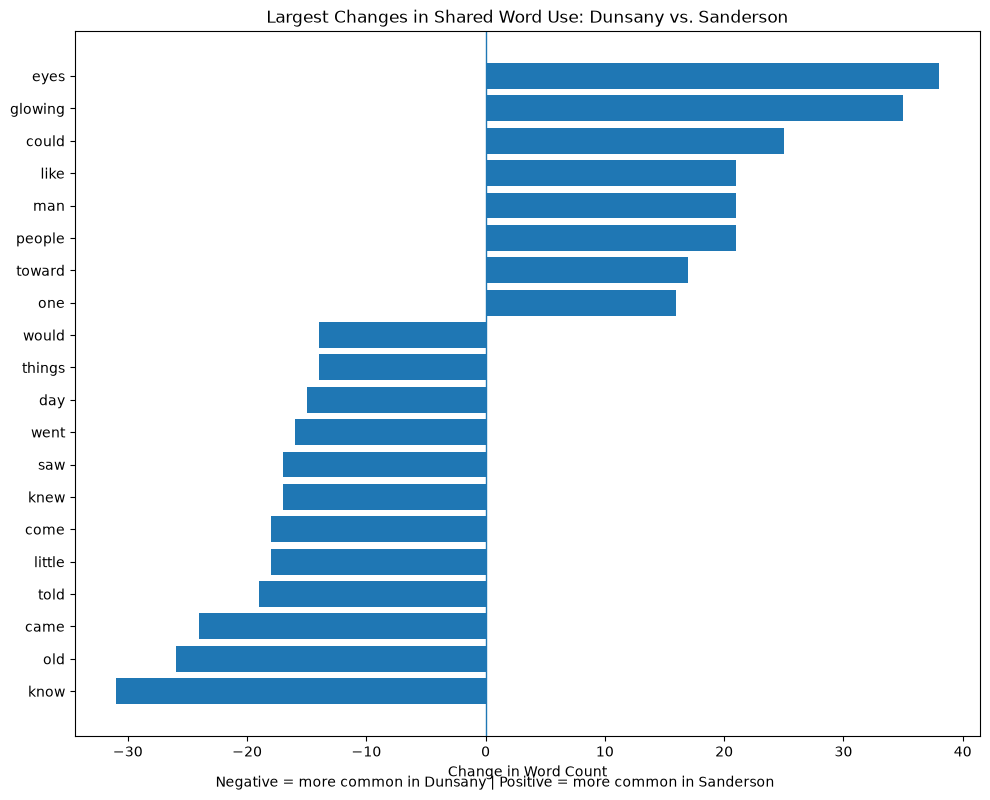

In [50]:
# shared word difference graph
shared_words = (
    set(dunsany_filtered_freq.keys())
    & set(sunlit_dunsany_filtered_freq.keys())
)

differences = {}

for word in shared_words:
    differences[word] = (
        sunlit_dunsany_filtered_freq[word]
        - dunsany_filtered_freq[word]
    )

largest_changes = sorted(
    differences.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)[:20]

largest_changes = sorted(
    largest_changes,
    key=lambda x: x[1]
)

words = [word for word, difference in largest_changes]
changes = [difference for word, difference in largest_changes]

plt.figure(figsize=(10, 8))

plt.barh(words, changes)
plt.axvline(0, linewidth=1)

plt.title("Largest Changes in Shared Word Use: Dunsany vs. Sanderson")
plt.xlabel("Change in Word Count")

plt.figtext(
    0.5,
    0.01,
    "Negative = more common in Dunsany | Positive = more common in Sanderson",
    ha="center"
)

plt.tight_layout()
plt.show()